# San Francisco-i bűnözési elemzés - V5 (Teljes verzió)
Ez a verzió tartalmazza az összes kért fejlesztést: adattisztítás, optimalizálás, haladó vizualizációk, klaszterezés, NLP elemzés és gépi tanulás.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="whitegrid")

## 1. fázis: Adattisztítás és Optimalizálás
Ebben a részben elvégezzük a hiányzó értékek kezelését, az adattípusok optimalizálását és a dátumok helyes formázását.

In [2]:
# Adatok betöltése
df = pd.read_csv('Map-Crime_Incidents-Previous_Three_Months.csv')

# 1. Adattisztítás: Hiányzó (NaN) értékek kezelése az IncidntNum oszlopban
df['IncidntNum'] = df['IncidntNum'].fillna(0).astype(int)

# 2. Adattípus optimalizálás: Kategória típusú oszlopok konvertálása (memóriatakarékosság)
df['Category'] = df['Category'].astype('category')
df['PdDistrict'] = df['PdDistrict'].astype('category')
df['DayOfWeek'] = df['DayOfWeek'].astype('category')
df['Resolution'] = df['Resolution'].astype('category')

# 3. Dátumkezelés: pd.to_datetime() használata a szeletelés helyett
df['Date'] = pd.to_datetime(df['Date'])
df['Time_DT'] = pd.to_datetime(df['Time'], format='%H:%M')
df['Time_Only'] = df['Time_DT'].dt.time

# Érvénytelen koordináták szűrése
df = df[(df['X'] < -120) & (df['Y'] > 30)]

print(f"Adatsorok száma: {len(df)}")
df.info()
df.head()

Adatsorok száma: 30760
<class 'pandas.DataFrame'>
RangeIndex: 30760 entries, 0 to 30759
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   IncidntNum  30760 non-null  int64              
 1   Category    30760 non-null  category           
 2   Descript    30760 non-null  str                
 3   DayOfWeek   30760 non-null  category           
 4   Date        30760 non-null  datetime64[us, UTC]
 5   Time        30760 non-null  str                
 6   PdDistrict  30760 non-null  category           
 7   Resolution  30760 non-null  category           
 8   Address     30760 non-null  str                
 9   X           30760 non-null  float64            
 10  Y           30760 non-null  float64            
 11  Location    30760 non-null  str                
 12  Time_DT     30760 non-null  datetime64[us]     
 13  Time_Only   30760 non-null  object             
dtypes: category(4), datetime64

,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location,Time_DT,Time_Only
0,0,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,2014-08-31 07:00:00+00:00,20:30,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,"(37.7909741243888, -122.417392830334)",1900-01-01 20:30:00,20:30:00
1,0,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,2014-08-31 07:00:00+00:00,14:30,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,"(37.7963018736036, -122.404417620748)",1900-01-01 14:30:00,14:30:00
2,0,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,2014-08-31 07:00:00+00:00,11:30,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,"(37.7894347630337, -122.406958660602)",1900-01-01 11:30:00,11:30:00
3,0,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,2014-08-31 07:00:00+00:00,17:49,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214965, -122.419671780296)",1900-01-01 17:49:00,17:49:00
4,0,DRUG/NARCOTIC,POSSESSION OF COCAINE,Sunday,2014-08-31 07:00:00+00:00,18:05,NORTHERN,"ARREST, BOOKED",LARKIN ST / OFARRELL ST,-122.417904,37.785167,"(37.7851670875814, -122.417903977564)",1900-01-01 18:05:00,18:05:00


## 1. fázis: Statisztikai diagramok
Bűncselekmények eloszlása kategória és a hét napjai szerint.

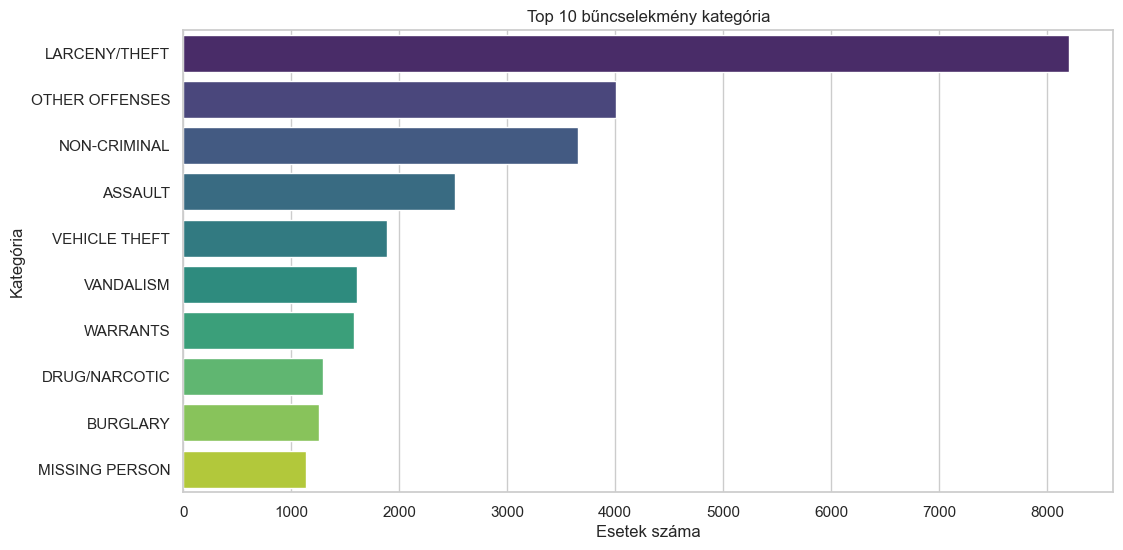

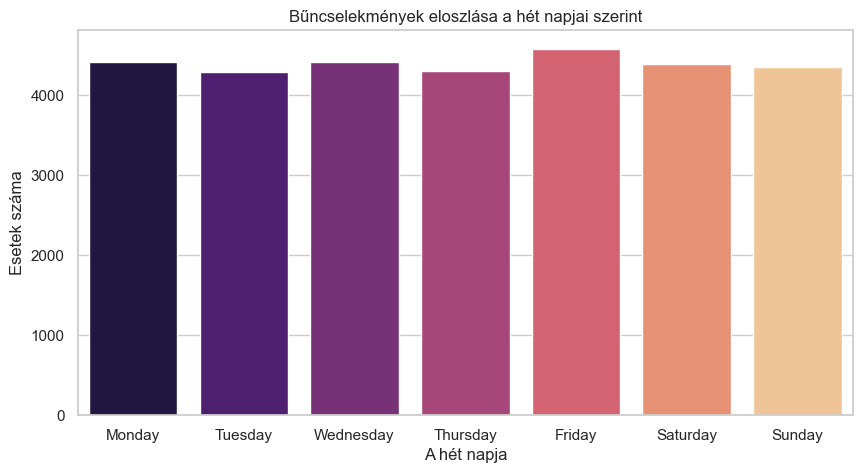

In [3]:
# Bűncselekmények eloszlása kategóriák szerint (Top 10)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Category', order=df['Category'].value_counts().iloc[:10].index, palette='viridis')
plt.title('Top 10 bűncselekmény kategória')
plt.xlabel('Esetek száma')
plt.ylabel('Kategória')
plt.show()

# Bűncselekmények a hét napjai szerint
plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='DayOfWeek', order=days_order, palette='magma')
plt.title('Bűncselekmények eloszlása a hét napjai szerint')
plt.xlabel('A hét napja')
plt.ylabel('Esetek száma')
plt.show()

## 1. fázis: Interaktív térképes vizualizáció
MarkerCluster és HeatMap használata a gócpontok átlátható megjelenítéséhez.

In [4]:
# Alaptérkép létrehozása
sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12)

# Hőtérkép (HeatMap) hozzáadása (mintavétel a teljesítményért)
heat_data = [[row['Y'], row['X']] for index, row in df.sample(min(5000, len(df))).iterrows()]
HeatMap(heat_data, radius=15).add_to(sf_map)

# MarkerCluster hozzáadása (jelölők csoportosítása)
marker_cluster = MarkerCluster(name='Bűnügyi esetek').add_to(sf_map)
# Mintavétel 1000 pontra a böngésző tehermentesítése érdekében
map_sample = df.sample(min(1000, len(df)))
for index, row in map_sample.iterrows():
    folium.Marker(
        location=[row['Y'], row['X']],
        popup=f"<b>{row['Category']}</b><br>{row['Descript']}<br>{row['Time']}",
    ).add_to(marker_cluster)

sf_map

## 2. fázis: Jellemző-kinyerés (Feature Engineering)
Az óra kinyerése és a napszakok (Time_of_Day) meghatározása.

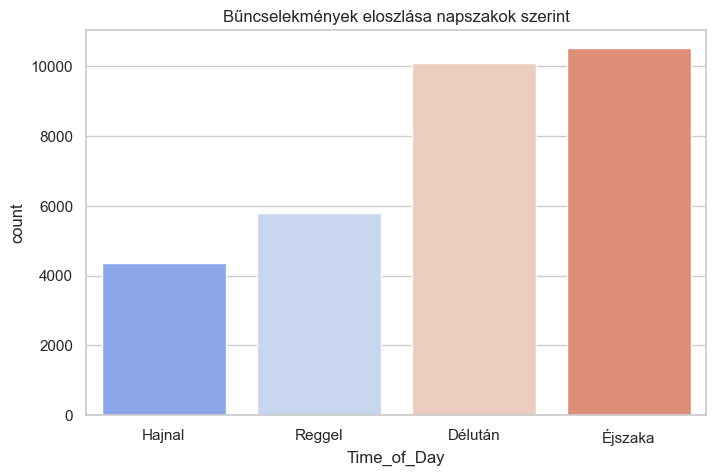

In [5]:
# Óra kinyerése
df['Hour'] = df['Time_DT'].dt.hour

# Napszakok meghatározása
def categorize_time(hour):
    if 0 <= hour < 6: return 'Hajnal'
    elif 6 <= hour < 12: return 'Reggel'
    elif 12 <= hour < 18: return 'Délután'
    else: return 'Éjszaka'

df['Time_of_Day'] = df['Hour'].apply(categorize_time)
df['Time_of_Day'] = df['Time_of_Day'].astype('category')

# Napszakok vizualizációja
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Time_of_Day', order=['Hajnal', 'Reggel', 'Délután', 'Éjszaka'], palette='coolwarm')
plt.title('Bűncselekmények eloszlása napszakok szerint')
plt.show()

## 2. fázis: Térbeli klaszterezés (DBSCAN Hotspots)
Automatikus gócpont-keresés a koordináták alapján.

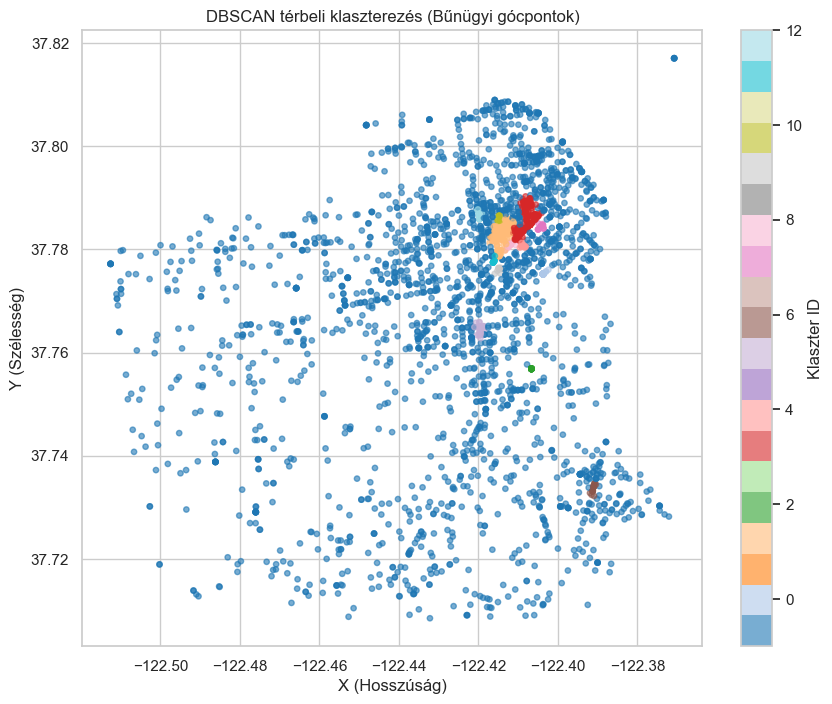

In [6]:
# Mintavétel a klaszterezéshez
coords = df[['X', 'Y']].sample(min(3000, len(df)))

# DBSCAN algoritmus futtatása
# eps: maximális távolság két pont között, min_samples: minimum pont egy klaszterhez
db = DBSCAN(eps=0.001, min_samples=15).fit(coords[['X', 'Y']])
coords['Cluster'] = db.labels_

# Klaszterek vizualizációja (a -1 a zaj/nem klaszterezett pontokat jelöli)
plt.figure(figsize=(10, 8))
plt.scatter(coords['X'], coords['Y'], c=coords['Cluster'], cmap='tab20', s=15, alpha=0.6)
plt.title('DBSCAN térbeli klaszterezés (Bűnügyi gócpontok)')
plt.xlabel('X (Hosszúság)')
plt.ylabel('Y (Szélesség)')
plt.colorbar(label='Klaszter ID')
plt.show()

## 2. fázis: NLP és Szövegbányászat
A leírások (Descript) előfeldolgozása és szófelhő generálása.

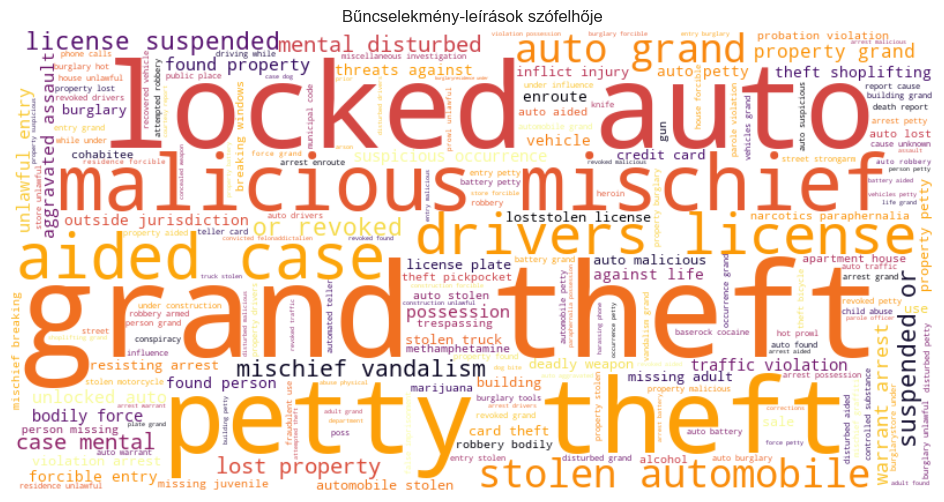

In [7]:
# Egyszerű szöveges előfeldolgozás
def preprocess_text(text):
    text = str(text).lower() # Kisbetűsítés
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text) # Írásjelek eltávolítása
    return text

df['Clean_Descript'] = df['Descript'].apply(preprocess_text)

# Stop words (gyakori töltelékszavak) listája
stop_words = set(['of', 'and', 'the', 'to', 'for', 'with', 'in', 'on', 'at', 'by', 'from', 'a', 'an'])

# Szófelhő generálása
all_text = " ".join(df['Clean_Descript'])
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    stopwords=stop_words,
    colormap='inferno'
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Bűncselekmény-leírások szófelhője')
plt.show()

## 2. fázis: Prediktív modellezés (XGBoost)
Bűncselekmény kategória előrejelzése a környezeti adatok alapján.

XGBoost modell tanítása folyamatban...


Tanítás kész.
                             precision    recall  f1-score   support

                      ARSON       0.00      0.00      0.00        12
                    ASSAULT       0.17      0.06      0.08       504
                   BURGLARY       0.22      0.04      0.07       251
         DISORDERLY CONDUCT       0.00      0.00      0.00        14
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00        19
              DRUG/NARCOTIC       0.36      0.26      0.30       258
                DRUNKENNESS       0.00      0.00      0.00        28
               EMBEZZLEMENT       0.00      0.00      0.00         4
     FORGERY/COUNTERFEITING       0.00      0.00      0.00        18
                      FRAUD       0.00      0.00      0.00       115
                 KIDNAPPING       0.00      0.00      0.00        26
              LARCENY/THEFT       0.34      0.82      0.49      1641
                LIQUOR LAWS       0.00      0.00      0.00         7
             MISSIN

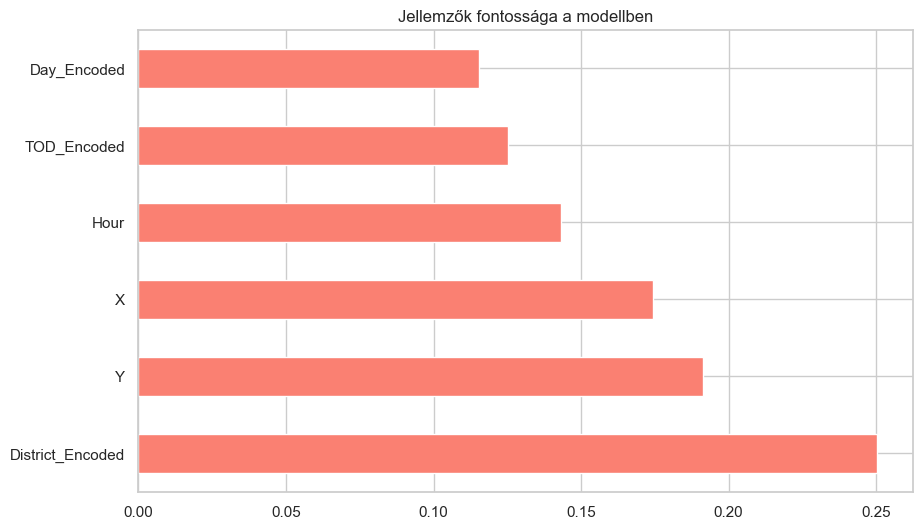

In [8]:
# Adatok előkészítése (Ritka kategóriák szűrése a stabilitásért)
cat_counts = df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= 15].index
df_ml = df[df['Category'].isin(valid_cats)].copy()

# Label Encoding
le_cat = LabelEncoder()
le_day = LabelEncoder()
le_dist = LabelEncoder()
le_tod = LabelEncoder()

y = le_cat.fit_transform(df_ml['Category'])
df_ml['Day_Encoded'] = le_day.fit_transform(df_ml['DayOfWeek'])
df_ml['District_Encoded'] = le_dist.fit_transform(df_ml['PdDistrict'])
df_ml['TOD_Encoded'] = le_tod.fit_transform(df_ml['Time_of_Day'])

# Jellemzők kiválasztása
features = ['Day_Encoded', 'District_Encoded', 'Hour', 'X', 'Y', 'TOD_Encoded']
X = df_ml[features]

# Tanító és teszt halmaz szétválasztása
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost osztályozó tanítása
clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    objective='multi:softprob',
    eval_metric='mlogloss'
)

print("XGBoost modell tanítása folyamatban...")
clf.fit(X_train, y_train)
print("Tanítás kész.")

# Kiértékelés
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_cat.classes_, zero_division=0))

# Jellemzők fontossága
plt.figure(figsize=(10, 6))
pd.Series(clf.feature_importances_, index=features).nlargest(10).plot(kind='barh', color='salmon')
plt.title('Jellemzők fontossága a modellben')
plt.show()